# Tutorial 3: Frequency Domain Image Analysis and Filtering

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

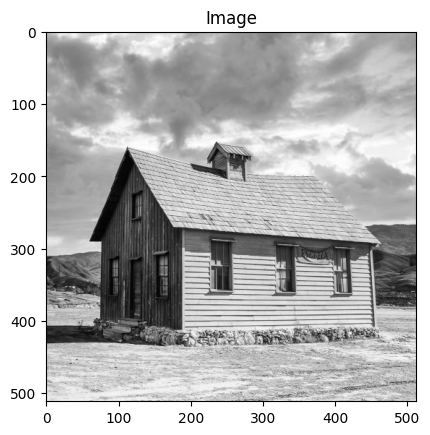

In [2]:
image = cv2.imread('frequency_analysis_tutorial_3.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(image, cmap='gray')
plt.title("Image")
plt.show()

### Discrete Fourier Transform on an Image


In [3]:
def dft_1d(input):
  length = len(input)
  x = []

  for n in range(length):
    x_n = 0

    for k in range(length):
      e = np.exp(-2j * np.pi * k * n / length)
      x_n += input[k] * e

    x.append(x_n)
  return np.array(x)

def dft_2d(input):
  image = np.zeros(input.shape, dtype=np.complex128)
  for col in range(image.shape[1]):
    image[:, col] = dft_1d(input[:, col])

  for row in range(image.shape[0]):
    image[row, :] = dft_1d(image[row,:])

  return image

def idft_1d(input):
  length = len(input)
  x = []

  for n in range(length):
    x_n = 0

    for k in range(length):
      e = np.exp(2j * np.pi * k * n / length)
      x_n += input[k] * e

    x.append(x_n)
  return (np.array(x) / float(length))

def idft_2d(input):
  image = np.zeros(input.shape, dtype=np.complex128)
  for col in range(image.shape[1]):
    image[:, col] = idft_1d(input[:, col])

  for row in range(image.shape[0]):
    image[row, :] = idft_1d(image[row,:])

  return image

def shift_2d(input):
  output = np.zeros_like(input)

  output[:(output.shape[0] // 2), :(output.shape[1] // 2)] = input[(input.shape[0] // 2):, (input.shape[1] // 2):]
  output[:(output.shape[0] // 2), (output.shape[1] // 2):] = input[(input.shape[0] // 2):, :(input.shape[1] // 2)]
  output[(output.shape[0] // 2):, :(output.shape[1] // 2)] = input[:(input.shape[0] // 2), (input.shape[1] // 2):]
  output[(output.shape[0] // 2):, (output.shape[1] // 2):] = input[:(input.shape[0] // 2), :(input.shape[1] // 2)]

  return output

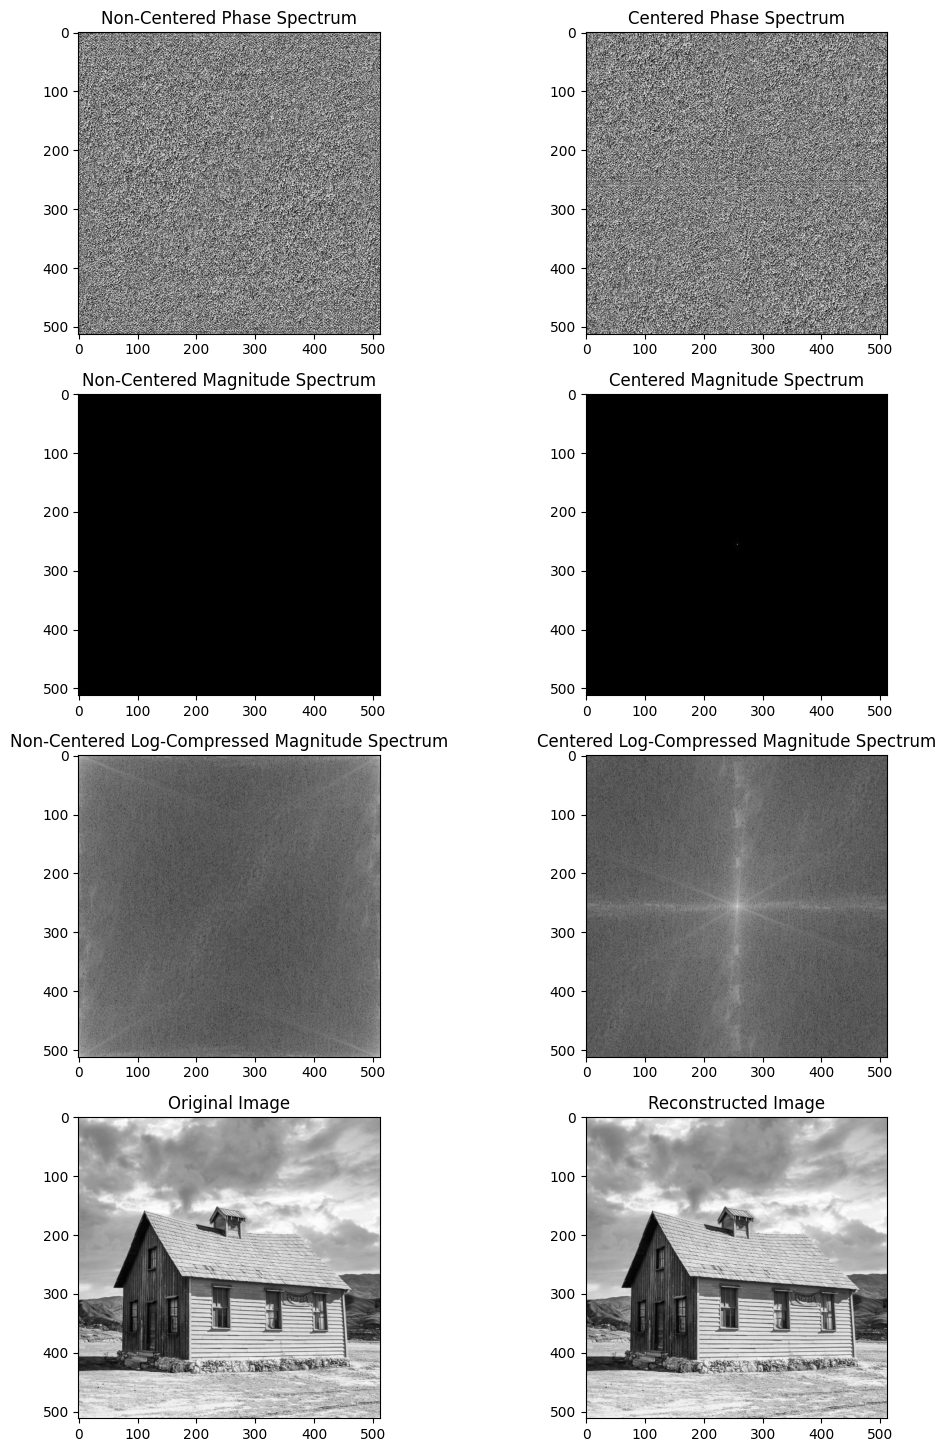

In [4]:
freq = dft_2d(image.astype(np.float32))
freq_shifted = shift_2d(freq)
recon = idft_2d(freq)

plt.figure(figsize=(12.0, 18.0))
plt.subplot(4, 2, 1).imshow(np.angle(freq), cmap='gray')
plt.title("Non-Centered Phase Spectrum")
plt.subplot(4, 2, 2).imshow(np.angle(freq_shifted), cmap='gray')
plt.title("Centered Phase Spectrum")
plt.subplot(4, 2, 3).imshow(np.abs(freq), cmap='gray')
plt.title("Non-Centered Magnitude Spectrum")
plt.subplot(4, 2, 4).imshow(np.abs(freq_shifted), cmap='gray')
plt.title("Centered Magnitude Spectrum")
plt.subplot(4, 2, 5).imshow(np.log(np.abs(freq)), cmap='gray')
plt.title("Non-Centered Log-Compressed Magnitude Spectrum")
plt.subplot(4, 2, 6).imshow(np.log(np.abs(freq_shifted)), cmap='gray')
plt.title("Centered Log-Compressed Magnitude Spectrum")
plt.subplot(4, 2, 7).imshow(image, cmap='gray')
plt.title("Original Image")
plt.subplot(4, 2, 8).imshow(np.real(recon), cmap='gray')
plt.title("Reconstructed Image")
plt.show()

### Discrete Fourier Transform on an Image


### DFT and IDFT Implementations in Numpy and OpenCV


(512, 512)
(512, 512, 2)
(41860045+0j)
[41860048.        0.]
(41860050+0j)


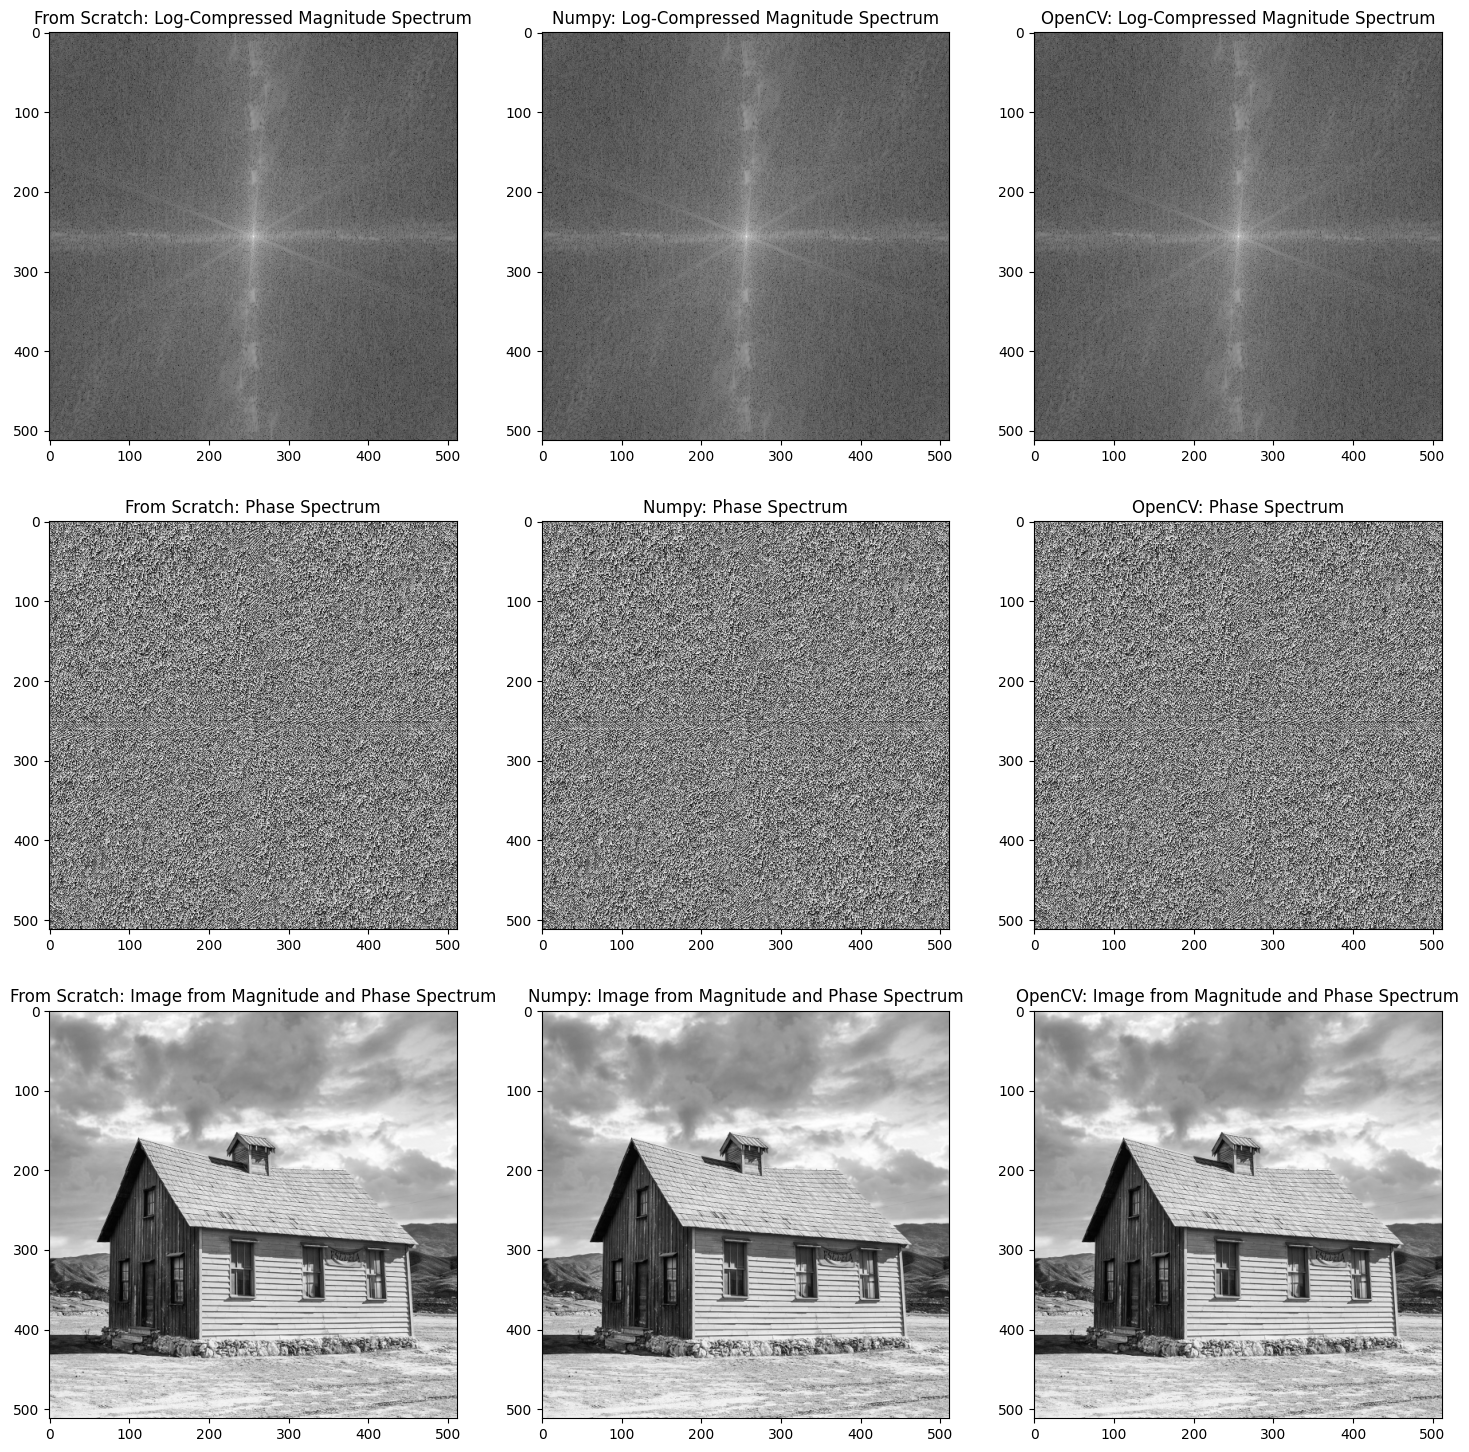

In [5]:
freq_np = np.fft.fft2(image)
freq_cv2 = cv2.dft(image.astype(np.float32), flags=cv2.DFT_COMPLEX_OUTPUT)

print(freq_np.shape)
print(freq_cv2.shape)

print(freq_np[0, 0])
print(freq_cv2[0, 0])

freq_cv2_complex = freq_cv2[:, :, 0] + 1j * freq_cv2[:, :, 1]
print(freq_cv2_complex[0, 0])

freq_shifted_np = np.fft.fftshift(freq_np)
freq_shifted_cv2 = np.fft.fftshift(freq_cv2_complex)

recon_image_np = np.fft.ifft2(freq_np)
recon_image_cv2 = cv2.idft(freq_cv2, flags=cv2.DFT_SCALE | cv2.DFT_REAL_OUTPUT)

plt.figure(figsize=(18.0, 18.0))
plt.subplot(3, 3, 1).imshow(np.log(np.abs(freq_shifted)), cmap='gray')
plt.title("From Scratch: Log-Compressed Magnitude Spectrum")
plt.subplot(3, 3, 2).imshow(np.log(np.abs(freq_shifted_np)), cmap='gray')
plt.title("Numpy: Log-Compressed Magnitude Spectrum")
plt.subplot(3, 3, 3).imshow(np.log(np.abs(freq_shifted_cv2)), cmap='gray')
plt.title("OpenCV: Log-Compressed Magnitude Spectrum")
plt.subplot(3, 3, 4).imshow(np.angle(freq_shifted), cmap='gray')
plt.title("From Scratch: Phase Spectrum")
plt.subplot(3, 3, 5).imshow(np.angle(freq_shifted_np), cmap='gray')
plt.title("Numpy: Phase Spectrum")
plt.subplot(3, 3, 6).imshow(np.angle(freq_shifted_cv2), cmap='gray')
plt.title("OpenCV: Phase Spectrum")
plt.subplot(3, 3, 7).imshow(np.real(recon), cmap='gray')
plt.title("From Scratch: Image from Magnitude and Phase Spectrum")
plt.subplot(3, 3, 8).imshow(np.real(recon_image_np), cmap='gray')
plt.title("Numpy: Image from Magnitude and Phase Spectrum")
plt.subplot(3, 3, 9).imshow(recon_image_cv2, cmap='gray')
plt.title("OpenCV: Image from Magnitude and Phase Spectrum")
plt.show()

### Importance of Magnitude Spectrum and Phase Spectrum


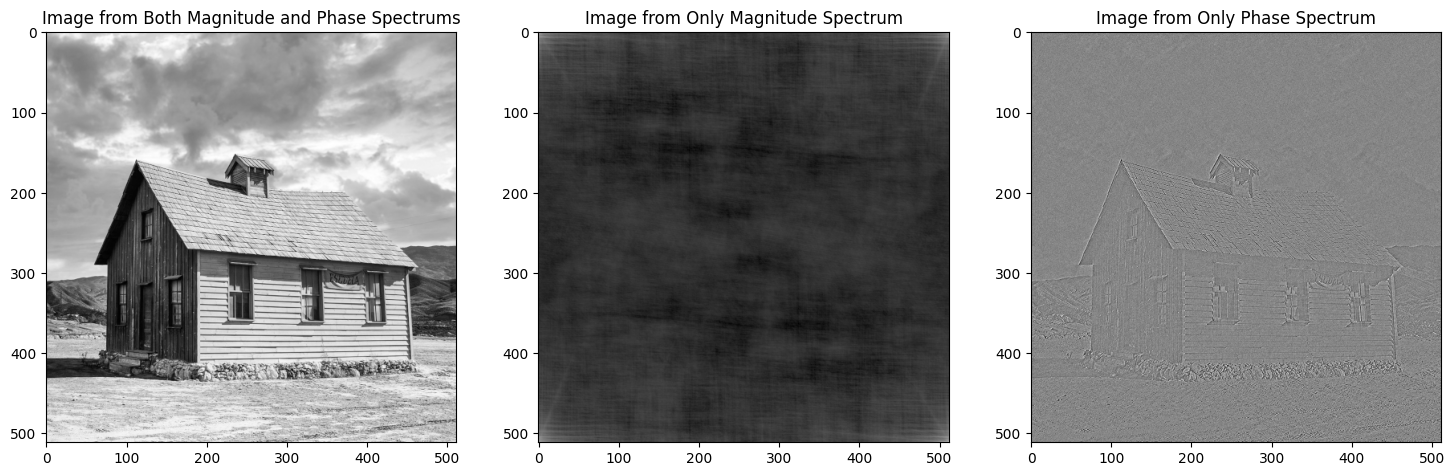

In [6]:
freq = np.fft.fft2(image)

freq_magnitude = np.abs(freq)
freq_phase = np.angle(freq)

freq_combined = (freq_magnitude * np.cos(freq_phase)) + 1j * (freq_magnitude * np.sin(freq_phase))
freq_only_magnitude = (freq_magnitude * np.cos(0.0)) + 1j * (freq_magnitude * np.sin(0.0))
freq_only_phase = (1.0 * np.cos(freq_phase)) + 1j * (1.0 * np.sin(freq_phase))

recon_image_combined = np.fft.ifft2(freq_combined)
recon_image_only_magnitude = np.fft.ifft2(freq_only_magnitude)
recon_image_only_phase = np.fft.ifft2(freq_only_phase)

plt.figure(figsize=(18.0, 6.0))
plt.subplot(1, 3, 1).imshow(np.real(recon_image_combined), cmap='gray')
plt.title("Image from Both Magnitude and Phase Spectrums")
plt.subplot(1, 3, 2).imshow(np.log(np.real(recon_image_only_magnitude)), cmap='gray')
plt.title("Image from Only Magnitude Spectrum")
plt.subplot(1, 3, 3).imshow(np.real(recon_image_only_phase), cmap='gray')
plt.title("Image from Only Phase Spectrum")
plt.show()

### Circular Convolution and Linear Convolution

In [7]:
def circular_convolution(image1, image2):
    height, width = image1.shape
    result = np.zeros((height, width), dtype=np.float32)

    for y in range(height):
        for x in range(width):
            sum_value = 0
            for j in range(height):
                for i in range(width):
                    y_idx = (y - j) % height
                    x_idx = (x - i) % width
                    sum_value += image1[j, i] * image2[y_idx, x_idx]
            result[y, x] = sum_value

    return result

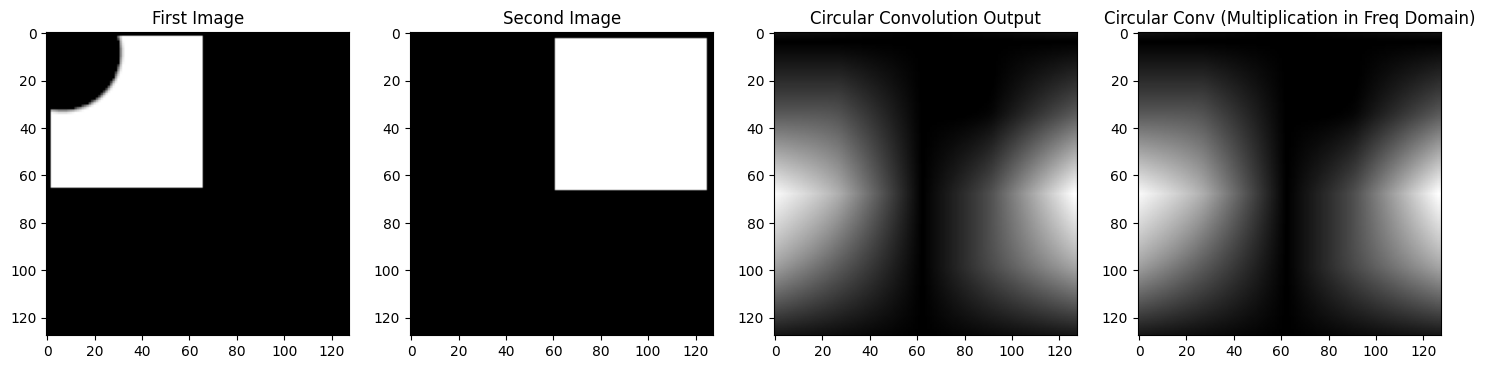

In [8]:
image = cv2.imread('frequency_analysis_tutorial_3_first.png', cv2.IMREAD_GRAYSCALE)
image_2 = cv2.imread('frequency_analysis_tutorial_3_second.png', cv2.IMREAD_GRAYSCALE)

circular_conv_output = circular_convolution(image.astype(np.float32), image_2.astype(np.float32))

freq = np.fft.fft2(image)
freq_2 = np.fft.fft2(image_2)

freq_mul = freq * freq_2

recon_image = np.fft.ifft2(freq_mul)

plt.figure(figsize=(18.0, 6.0))
plt.subplot(1, 4, 1).imshow(image, cmap='gray')
plt.title("First Image")
plt.subplot(1, 4, 2).imshow(image_2, cmap='gray')
plt.title("Second Image")
plt.subplot(1, 4, 3).imshow(circular_conv_output, cmap='gray')
plt.title("Circular Convolution Output")
plt.subplot(1, 4, 4).imshow(np.real(recon_image), cmap='gray')
plt.title("Circular Conv (Multiplication in Freq Domain)")
plt.show()

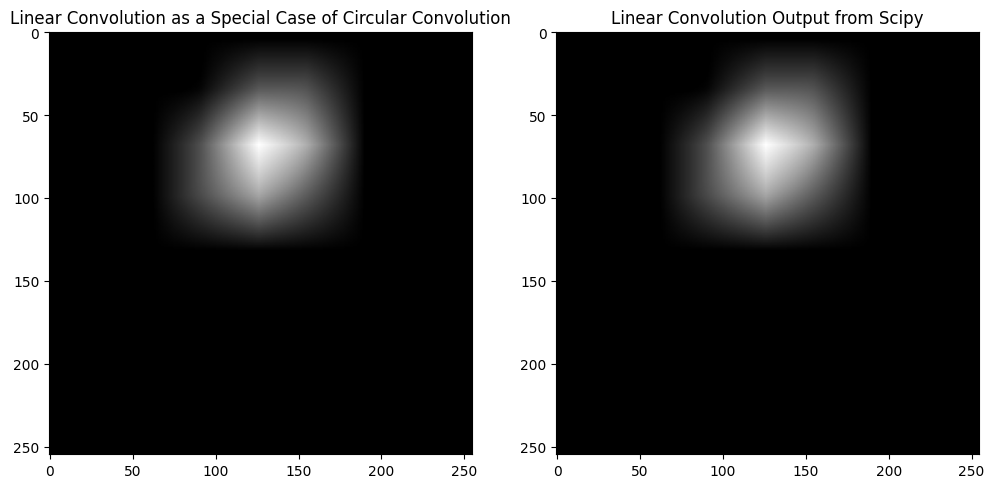

In [9]:
image_padded = np.zeros(shape=(image.shape[0] + image_2.shape[0] - 1, image.shape[1] + image_2.shape[1] - 1))
image_2_padded = np.zeros(shape=(image.shape[0] + image_2.shape[0] - 1, image.shape[1] + image_2.shape[1] - 1))

image_padded[:image.shape[0], :image.shape[1]] = image
image_2_padded[:image_2.shape[0], :image_2.shape[1]] = image_2

freq = np.fft.fft2(image_padded)
freq_2 = np.fft.fft2(image_2_padded)

freq_mul = freq * freq_2

recon_image = np.fft.ifft2(freq_mul)

from scipy.signal import convolve2d
scipy_output = convolve2d(image.astype(np.float32), image_2.astype(np.float32), mode='full', boundary='fill')

plt.figure(figsize=(12.0, 6.0))
plt.subplot(1, 2, 1).imshow(np.real(recon_image), cmap='gray')
plt.title("Linear Convolution as a Special Case of Circular Convolution")
plt.subplot(1, 2, 2).imshow(scipy_output, cmap='gray')
plt.title("Linear Convolution Output from Scipy")
plt.show()

### Filtering in Frequency Domain

In [10]:
def ideal_lpf(input, cutoff = 0.25):
  row, col = input.shape
  cutoff_size = float(cutoff * row)

  centre_point = input.shape[0] // 2, input.shape[1] // 2

  mask = np.zeros_like(input, dtype = np.float32)

  for i in range(row):
    for j in range(col):
      if np.linalg.norm(np.array([i, j]) - np.array([centre_point[0], centre_point[1]])) < (0.5 * cutoff_size):
        mask[i, j] = 1.0

  return input * mask

def ideal_hpf(input, cutoff = 0.25):
  row, col = input.shape
  cutoff_size = float(cutoff * row)

  centre_point = input.shape[0] // 2, input.shape[1] // 2

  mask = np.zeros_like(input, dtype = np.float32)

  for i in range(row):
    for j in range(col):
      if np.linalg.norm(np.array([i, j]) - np.array([centre_point[0], centre_point[1]])) > (0.5 * cutoff_size):
        mask[i, j] = 1.0

  return input * mask

def create_gaussian_filter(shape, cutoff, filter_type='low'):
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    u = np.arange(0, rows, 1)
    v = np.arange(0, cols, 1)
    u, v = np.meshgrid(u - crow, v - ccol)
    d = np.sqrt(u ** 2 + v ** 2)

    if filter_type == 'low':
        H = np.exp(-d ** 2 / (2 * cutoff ** 2))
    elif filter_type == 'high':
        H = 1 - np.exp(-d ** 2 / (2 * cutoff ** 2))
    else:
        raise ValueError("Unknown filter type")

    return H

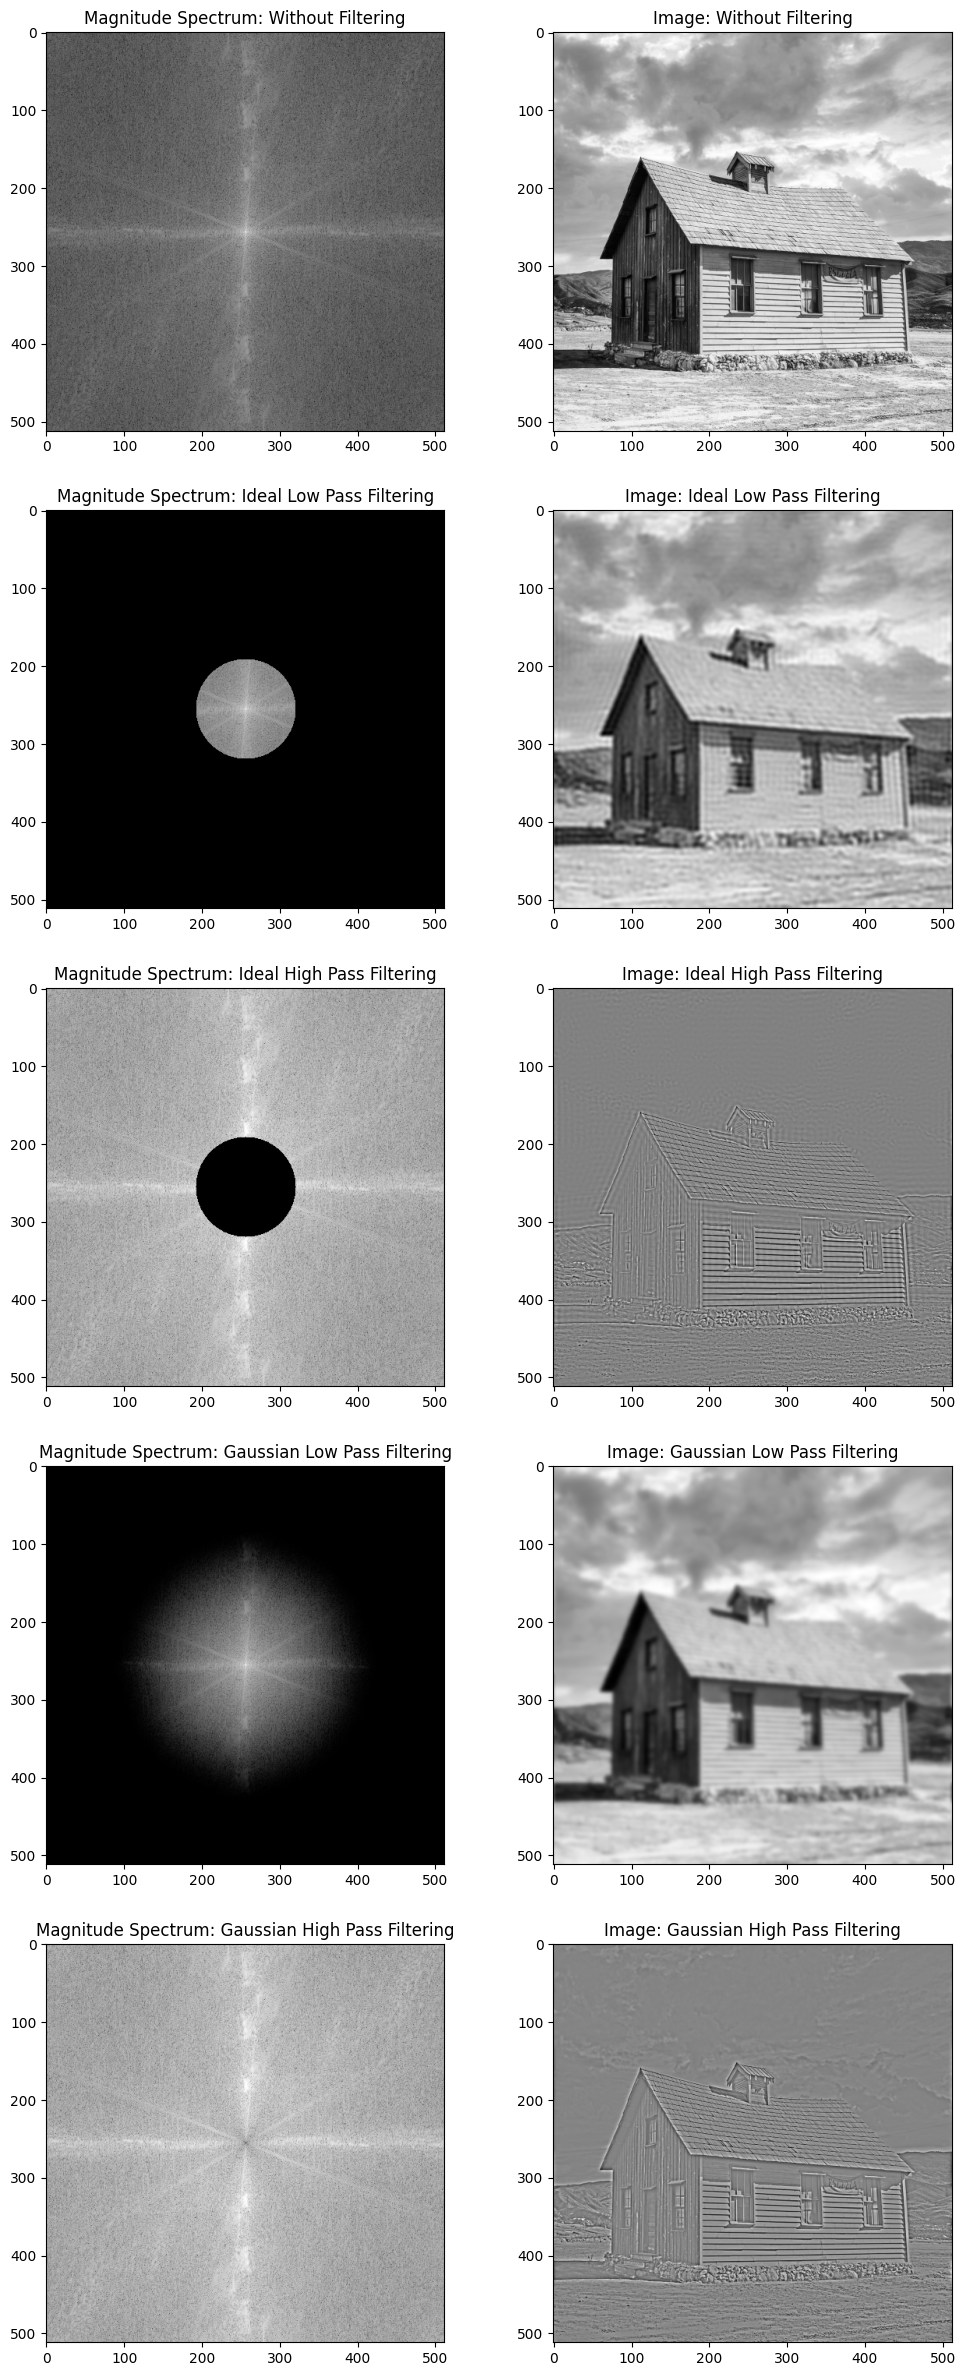

In [11]:
image = cv2.imread('frequency_analysis_tutorial_3.png', cv2.IMREAD_GRAYSCALE)

freq = np.fft.fft2(image)
freq = np.fft.fftshift(freq)

freq_magnitude = np.abs(freq)
freq_phase = np.angle(freq)

freq_magnitude_ideal_lpf = ideal_lpf(freq_magnitude.copy())
freq_magnitude_ideal_hpf = ideal_hpf(freq_magnitude.copy())
freq_magnitude_gaussian_lpf = create_gaussian_filter(freq_magnitude.shape, cutoff=35.0, filter_type='low') * freq_magnitude
freq_magnitude_gaussian_hpf = create_gaussian_filter(freq_magnitude.shape, cutoff=35.0, filter_type='high') * freq_magnitude

freq_combined = (freq_magnitude * np.cos(freq_phase)) + 1j * (freq_magnitude * np.sin(freq_phase))
freq_combined_ideal_lpf = (freq_magnitude_ideal_lpf * np.cos(freq_phase)) + 1j * (freq_magnitude_ideal_lpf * np.sin(freq_phase))
freq_combined_ideal_hpf = (freq_magnitude_ideal_hpf * np.cos(freq_phase)) + 1j * (freq_magnitude_ideal_hpf * np.sin(freq_phase))
freq_combined_gaussian_lpf = (freq_magnitude_gaussian_lpf * np.cos(freq_phase)) + 1j * (freq_magnitude_gaussian_lpf * np.sin(freq_phase))
freq_combined_gaussian_hpf = (freq_magnitude_gaussian_hpf * np.cos(freq_phase)) + 1j * (freq_magnitude_gaussian_hpf * np.sin(freq_phase))

recon_image_combined = np.fft.ifft2(np.fft.fftshift(freq_combined))
recon_image_combined_ideal_lpf = np.fft.ifft2(np.fft.fftshift(freq_combined_ideal_lpf))
recon_image_combined_ideal_hpf = np.fft.ifft2(np.fft.fftshift(freq_combined_ideal_hpf))
recon_image_combined_gaussian_lpf = np.fft.ifft2(np.fft.fftshift(freq_combined_gaussian_lpf))
recon_image_combined_gaussian_hpf = np.fft.ifft2(np.fft.fftshift(freq_combined_gaussian_hpf))

plt.figure(figsize=(12.0, 30.0))
plt.subplot(5, 2, 1).imshow(np.log(freq_magnitude), cmap='gray')
plt.title("Magnitude Spectrum: Without Filtering")
plt.subplot(5, 2, 2).imshow(np.real(recon_image_combined), cmap='gray')
plt.title("Image: Without Filtering")
plt.subplot(5, 2, 3).imshow(np.log(freq_magnitude_ideal_lpf + 1.0), cmap='gray')
plt.title("Magnitude Spectrum: Ideal Low Pass Filtering")
plt.subplot(5, 2, 4).imshow(np.real(recon_image_combined_ideal_lpf), cmap='gray')
plt.title("Image: Ideal Low Pass Filtering")
plt.subplot(5, 2, 5).imshow(np.log(freq_magnitude_ideal_hpf + 1.0), cmap='gray')
plt.title("Magnitude Spectrum: Ideal High Pass Filtering")
plt.subplot(5, 2, 6).imshow(np.real(recon_image_combined_ideal_hpf), cmap='gray')
plt.title("Image: Ideal High Pass Filtering")
plt.subplot(5, 2, 7).imshow(np.log(freq_magnitude_gaussian_lpf + 1.0), cmap='gray')
plt.title("Magnitude Spectrum: Gaussian Low Pass Filtering")
plt.subplot(5, 2, 8).imshow(np.real(recon_image_combined_gaussian_lpf), cmap='gray')
plt.title("Image: Gaussian Low Pass Filtering")
plt.subplot(5, 2, 9).imshow(np.log(freq_magnitude_gaussian_hpf + 1.0), cmap='gray')
plt.title("Magnitude Spectrum: Gaussian High Pass Filtering")
plt.subplot(5, 2, 10).imshow(np.real(recon_image_combined_gaussian_hpf), cmap='gray')
plt.title("Image: Gaussian High Pass Filtering")
plt.show()